# Checkpoint 1 
## (Do not remove any comments that start with"# @@@".) 

Reminder: 

- You are being evaluated for completion and effort in this checkpoint. 
- Avoid manual labor / hard coding as much as possible, everything we've taught you so far are meant to simplify and automate your process.
- Please do not remove any comment that starts with: "# @@@". 

We will be working with the same `states_edu.csv` that you should already be familiar with from the tutorial.

We investigated Grade 8 reading score in the tutorial. For this checkpoint, you are asked to investigate another test. Here's an overview:

* Choose a specific response variable to focus on
>Grade 4 Math, Grade 4 Reading, Grade 8 Math
* Pick or create features to use
>Will all the features be useful in predicting test score? Are some more important than others? Should you standardize, bin, or scale the data?
* Explore the data as it relates to that test
>Create at least 2 visualizations (graphs), each with a caption describing the graph and what it tells us about the data
* Create training and testing data
>Do you want to train on all the data? Only data from the last 10 years? Only Michigan data?
* Train a ML model to predict outcome 
>Define what you want to predict, and pick a model in sklearn to use (see sklearn <a href="https://scikit-learn.org/stable/modules/linear_model.html">regressors</a>).


Include comments throughout your code! Every cleanup and preprocessing task should be documented.


I chose Grade 8 Math as the response variable because I want to investigate which educational and financial factors are most associated with eighth-grade math performance.

In [472]:
target = "AVG_MATH_8_SCORE"

<h2> Data Cleanup </h2>

Import `numpy`, `pandas`, and `matplotlib`.

(Feel free to import other libraries!)

In [473]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

Load in the "states_edu.csv" dataset and take a look at the head of the data

In [474]:
df = pd.read_csv("../data/states_edu.csv")
print("Dataframe Shape : ", df.shape)


Dataframe Shape :  (1715, 25)


LOAD AND INSPECT DATASET 

You should always familiarize yourself with what each column in the dataframe represents. Read about the states_edu dataset here: https://www.kaggle.com/noriuk/us-education-datasets-unification-project

In [475]:
df.head() 

,PRIMARY_KEY,STATE,YEAR,ENROLL,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,...,GRADES_4_G,GRADES_8_G,GRADES_12_G,GRADES_1_8_G,GRADES_9_12_G,GRADES_ALL_G,AVG_MATH_4_SCORE,AVG_MATH_8_SCORE,AVG_READING_4_SCORE,AVG_READING_8_SCORE
0,1992_ALABAMA,ALABAMA,1992,NaN,2678885.0,304177.0,1659028.0,715680.0,2653798.0,1481703.0,...,57948.0,58025.0,41167.0,NaN,NaN,731634.0,208.0,252.0,207.0,NaN
1,1992_ALASKA,ALASKA,1992,NaN,1049591.0,106780.0,720711.0,222100.0,972488.0,498362.0,...,9748.0,8789.0,6714.0,NaN,NaN,122487.0,NaN,NaN,NaN,NaN
2,1992_ARIZONA,ARIZONA,1992,NaN,3258079.0,297888.0,1369815.0,1590376.0,3401580.0,1435908.0,...,55433.0,49081.0,37410.0,NaN,NaN,673477.0,215.0,265.0,209.0,NaN
3,1992_ARKANSAS,ARKANSAS,1992,NaN,1711959.0,178571.0,958785.0,574603.0,1743022.0,964323.0,...,34632.0,36011.0,27651.0,NaN,NaN,441490.0,210.0,256.0,211.0,NaN
4,1992_CALIFORNIA,CALIFORNIA,1992,NaN,26260025.0,2072470.0,16546514.0,7641041.0,27138832.0,14358922.0,...,418418.0,363296.0,270675.0,NaN,NaN,5254844.0,208.0,261.0,202.0,NaN


In [476]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1715 entries, 0 to 1714
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   PRIMARY_KEY                   1715 non-null   object 
 1   STATE                         1715 non-null   object 
 2   YEAR                          1715 non-null   int64  
 3   ENROLL                        1224 non-null   float64
 4   TOTAL_REVENUE                 1275 non-null   float64
 5   FEDERAL_REVENUE               1275 non-null   float64
 6   STATE_REVENUE                 1275 non-null   float64
 7   LOCAL_REVENUE                 1275 non-null   float64
 8   TOTAL_EXPENDITURE             1275 non-null   float64
 9   INSTRUCTION_EXPENDITURE       1275 non-null   float64
 10  SUPPORT_SERVICES_EXPENDITURE  1275 non-null   float64
 11  OTHER_EXPENDITURE             1224 non-null   float64
 12  CAPITAL_OUTLAY_EXPENDITURE    1275 non-null   float64
 13  GRA

MISSING VALUE OVERVIEW

Use this space to rename columns, deal with missing data, etc. _(optional)_

We start by seeing if there are any duplicated data

In [477]:
df.duplicated().sum()

np.int64(0)

In [478]:
df["PRIMARY_KEY"].duplicated().sum()

np.int64(0)

No duplicate rows or duplicated primary keys were found, so no observations were removed for duplication.

In [479]:
# see for each variable how many missing data there is 
df.isna().sum() 

PRIMARY_KEY                        0
STATE                              0
YEAR                               0
ENROLL                           491
TOTAL_REVENUE                    440
FEDERAL_REVENUE                  440
STATE_REVENUE                    440
LOCAL_REVENUE                    440
TOTAL_EXPENDITURE                440
INSTRUCTION_EXPENDITURE          440
SUPPORT_SERVICES_EXPENDITURE     440
OTHER_EXPENDITURE                491
CAPITAL_OUTLAY_EXPENDITURE       440
GRADES_PK_G                      173
GRADES_KG_G                       83
GRADES_4_G                        83
GRADES_8_G                        83
GRADES_12_G                       83
GRADES_1_8_G                     695
GRADES_9_12_G                    644
GRADES_ALL_G                      83
AVG_MATH_4_SCORE                1150
AVG_MATH_8_SCORE                1113
AVG_READING_4_SCORE             1065
AVG_READING_8_SCORE             1153
dtype: int64

In [480]:
df["AVG_MATH_8_SCORE"].notna().sum()

np.int64(602)

In [481]:
# see the percentage of values that are missing out of the total
missing_percent = df.isna().mean() * 100
missing_percent.sort_values(ascending=False)

AVG_READING_8_SCORE             67.230321
AVG_MATH_4_SCORE                67.055394
AVG_MATH_8_SCORE                64.897959
AVG_READING_4_SCORE             62.099125
GRADES_1_8_G                    40.524781
GRADES_9_12_G                   37.551020
OTHER_EXPENDITURE               28.629738
ENROLL                          28.629738
LOCAL_REVENUE                   25.655977
CAPITAL_OUTLAY_EXPENDITURE      25.655977
SUPPORT_SERVICES_EXPENDITURE    25.655977
TOTAL_REVENUE                   25.655977
TOTAL_EXPENDITURE               25.655977
FEDERAL_REVENUE                 25.655977
STATE_REVENUE                   25.655977
INSTRUCTION_EXPENDITURE         25.655977
GRADES_PK_G                     10.087464
GRADES_8_G                       4.839650
GRADES_4_G                       4.839650
GRADES_ALL_G                     4.839650
GRADES_KG_G                      4.839650
GRADES_12_G                      4.839650
YEAR                             0.000000
PRIMARY_KEY                      0

We see that the most alarming characteristic of the dataset is that the test score variables have a big percentage of missing values. Therefore, a single global missing-value strategy would not be appropiate for every variable. 

INSPECT TARGET 

In [482]:
df["AVG_MATH_8_SCORE"].describe()

count    602.000000
mean     278.280731
std       10.343482
min      231.000000
25%      272.000000
50%      280.500000
75%      286.000000
max      301.000000
Name: AVG_MATH_8_SCORE, dtype: float64

Grade 8 Math is the response variable. Rows without a response value cannot contribute to supervised training or evaluation, so these observations are removed rather than imputed. Imputing the target would artificially create labels that the model is supposed to learn.

In [483]:
df = df.dropna(subset=["AVG_MATH_8_SCORE"])

In [484]:
print("Rows remaining:", len(df))

Rows remaining: 602


Only 602 of the original 1715 observations contain Grade 8 Math scores, so the target itself is the main source of data reduction

In [485]:
missing_after_target = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing_after_target.sort_values(
    "missing_percent",
    ascending=False
)

,missing_count,missing_percent
ENROLL,205,34.053156
GRADES_1_8_G,205,34.053156
OTHER_EXPENDITURE,205,34.053156
LOCAL_REVENUE,163,27.076412
TOTAL_REVENUE,163,27.076412
TOTAL_EXPENDITURE,163,27.076412
SUPPORT_SERVICES_EXPENDITURE,163,27.076412
STATE_REVENUE,163,27.076412
FEDERAL_REVENUE,163,27.076412
CAPITAL_OUTLAY_EXPENDITURE,163,27.076412


In [486]:
candidate_features = [
    "AVG_MATH_4_SCORE",
    "AVG_READING_4_SCORE",
    "AVG_READING_8_SCORE",
    "YEAR",
    "ENROLL",
    "TOTAL_EXPENDITURE",
    "INSTRUCTION_EXPENDITURE"
]

selected = []
for col in candidate_features:
    selected.append(col)

    remaining = df[selected + [target]].dropna().shape[0]

    print(
        f"After adding {col}: "
        f"{remaining} rows remaining"
    )

After adding AVG_MATH_4_SCORE: 564 rows remaining
After adding AVG_READING_4_SCORE: 521 rows remaining
After adding AVG_READING_8_SCORE: 478 rows remaining
After adding YEAR: 478 rows remaining
After adding ENROLL: 357 rows remaining
After adding TOTAL_EXPENDITURE: 357 rows remaining
After adding INSTRUCTION_EXPENDITURE: 357 rows remaining


The incremental complete-case analysis shows that most of the sample reduction occurs when ENROLL is introduced. Academic predictors reduce the dataset from 602 to 478 observations, while adding ENROLL causes a much larger drop to 357 observations. Adding total and instruction expenditure does not remove any additional rows. This suggests that the missingness of the financial features is largely aligned with missing enrollment data.

CONCLUSION OF MISSING DATA 

The dataset contains a substantial amount of missing data, especially in standardized test score and financial variables. Since Grade 8 Math is the response variable, observations with a missing target cannot be used for supervised learning and are therefore removed.

I do not remove all rows containing missing values at this stage, because doing so would discard a large fraction of the dataset. Instead, missing predictor values are handled later after selecting the final set of features, so that only observations missing variables actually used by the model are removed.

<h2>Exploratory Data Analysis (EDA) </h2>

TARGET DISTRIBUTION

Chosen one of Grade 4 Reading, Grade 4 Math, or Grade 8 Math to focus on: Grade 8 Math 

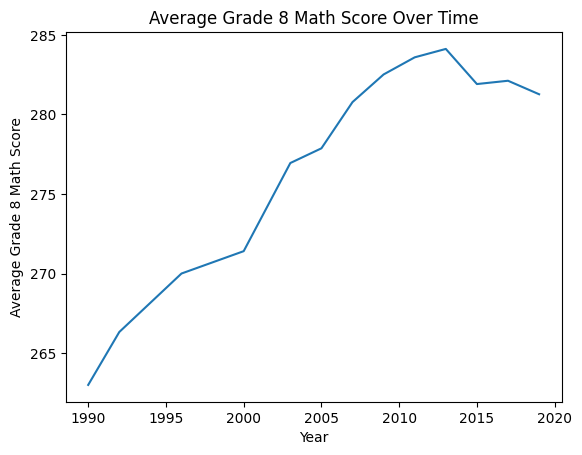

In [487]:
df.groupby("YEAR")["AVG_MATH_8_SCORE"].mean().plot()
plt.xlabel("Year")
plt.ylabel("Average Grade 8 Math Score")
plt.title("Average Grade 8 Math Score Over Time")
plt.show()

Grade 8 Math scores are concentrated around the high 270s, with a smaller number of lower-scoring observations forming the lower tail. 

TARGET CORRELATIONS

In [488]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

target_corr = (
    corr["AVG_MATH_8_SCORE"]
    .drop("AVG_MATH_8_SCORE")
    .sort_values(ascending=False)
)

print(target_corr[:10])


AVG_MATH_4_SCORE                0.910409
AVG_READING_8_SCORE             0.892087
AVG_READING_4_SCORE             0.825038
YEAR                            0.552717
LOCAL_REVENUE                   0.145453
GRADES_PK_G                     0.100716
SUPPORT_SERVICES_EXPENDITURE    0.099414
INSTRUCTION_EXPENDITURE         0.097090
TOTAL_REVENUE                   0.095045
TOTAL_EXPENDITURE               0.091851
Name: AVG_MATH_8_SCORE, dtype: float64


The strongest correlations are all previous or test scores. This suggests that academic performance is relatively persistent across grades and subjects. Grade 4 Math is especially informative, with a correlation above 0.9 with Grade 8 Math. However, these correlations should not be interpreted causally; they only indicate strong linear association.

HEATMAP

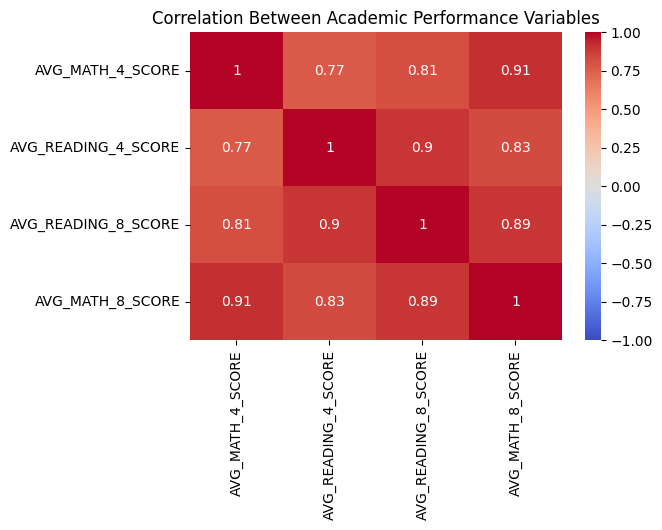

In [489]:
important_academic = [
    "AVG_MATH_4_SCORE",
    "AVG_READING_4_SCORE",
    "AVG_READING_8_SCORE",
    "AVG_MATH_8_SCORE"
]

plt.figure(figsize=(6, 4))

sns.heatmap(
    df[important_academic].corr(),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Academic Performance Variables")
plt.show()

The strongest predictors of Grade 8 Math are also highly correlated with one another. In particular, Grade 4 Reading and Grade 8 Reading have a correlation close to 0.90. This indicates redundancy among the academic predictors and suggests potential multicollinearity in a linear regression model. This motivates testing regularized models such as Ridge and Lasso later in the analysis.

BOXPLOTS AND OUTLIERS

See a boxplot for analyzing distribution, dispersion ans outliers 

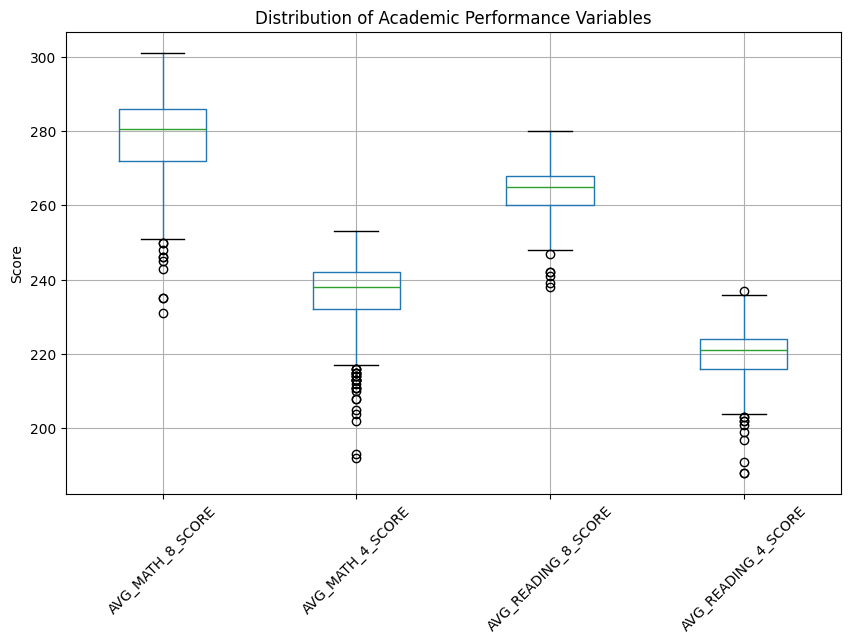

In [490]:
important_vars = [
    "AVG_MATH_8_SCORE",      # target
    "AVG_MATH_4_SCORE",
    "AVG_READING_8_SCORE",
    "AVG_READING_4_SCORE"
]

plt.figure(figsize=(10, 6))
df[important_vars].boxplot()

plt.title("Distribution of Academic Performance Variables")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

The academic score variables contain several observations outside the standard 1.5-IQR boxplot range, especially on the lower end. These values are not removed automatically, because they may represent genuine state-level differences in academic performance rather than data errors. I therefore retain them unless further inspection reveals implausible or inconsistent observations.

QUESTIONS 1-4

How many years of data are logged in our dataset? 

In [491]:
# @@@ 1
# Your Code
print(df["YEAR"].unique())
print("Total number of years : ", df["YEAR"].nunique())


[1992 2000 2003 2005 2007 2009 2011 2013 2015 1990 2017 1996 2019]
Total number of years :  13


Let's compare Michigan to Ohio. Which state has the higher average across all years in the test you chose?

In [492]:
# @@@ 2

state_means = (
    df[df["STATE"].isin(["MICHIGAN", "OHIO"])]
    .groupby("STATE")["AVG_MATH_8_SCORE"]
    .mean()
)

print(state_means)

STATE
MICHIGAN    276.166667
OHIO        282.250000
Name: AVG_MATH_8_SCORE, dtype: float64


Find the average for your chosen test across all states in 2019

In [493]:
# @@@ 3

df[df["YEAR"] == 2019]["AVG_MATH_8_SCORE"].mean()

np.float64(281.2641509433962)

For each state, find a maximum value for your chosen test score

In [494]:
# @@@ 4
df.groupby("STATE")["AVG_MATH_8_SCORE"].max()


STATE
ALABAMA                 269.0
ALASKA                  283.0
ARIZONA                 283.0
ARKANSAS                279.0
CALIFORNIA              277.0
COLORADO                292.0
CONNECTICUT             289.0
DELAWARE                284.0
DISTRICT_OF_COLUMBIA    269.0
DODEA                   293.0
FLORIDA                 281.0
GEORGIA                 281.0
HAWAII                  281.0
IDAHO                   287.0
ILLINOIS                285.0
INDIANA                 288.0
IOWA                    286.0
KANSAS                  290.0
KENTUCKY                282.0
LOUISIANA               273.0
MAINE                   289.0
MARYLAND                288.0
MASSACHUSETTS           301.0
MICHIGAN                280.0
MINNESOTA               295.0
MISSISSIPPI             274.0
MISSOURI                286.0
MONTANA                 293.0
NATIONAL                285.0
NEBRASKA                288.0
NEVADA                  278.0
NEW_HAMPSHIRE           296.0
NEW_JERSEY              296.0
NEW_

*Refer to the `Grouping and Aggregating` section in Tutorial 0 if you are stuck.

<h2> Feature Engineering </h2>

After exploring the data, you can choose to modify features that you would use to predict the performance of the students on your chosen response variable. 

You can also create your own features. For example, perhaps you figured that maybe a state's expenditure per student may affect their overall academic performance so you create a expenditure_per_student feature.

Use this space to modify or create features.

CREATE PER-STUDENT FEATURES

In [495]:
# @@@ 5

df["EXPENDITURE_PER_STUDENT"] = df["TOTAL_EXPENDITURE"] / df["ENROLL"]
df["INSTRUCTION_PER_STUDENT"] = df["INSTRUCTION_EXPENDITURE"] / df["ENROLL"]
df["INSTRUCTION_SHARE"] = df["INSTRUCTION_EXPENDITURE"] / df["TOTAL_EXPENDITURE"]



Feature engineering justification: Raw expenditure values are heavily influenced by state size. I created per-student expenditure features so that spending can be compared more fairly across states with very different enrollment levels.

COMPARE RAW VS NEW CORRELATION FEATURES 

In [496]:
df[
    [
        "EXPENDITURE_PER_STUDENT",
        "INSTRUCTION_PER_STUDENT",
        "INSTRUCTION_SHARE",
        "AVG_MATH_8_SCORE"
    ]
].corr()["AVG_MATH_8_SCORE"].sort_values(ascending=False)

AVG_MATH_8_SCORE           1.000000
INSTRUCTION_PER_STUDENT    0.348552
EXPENDITURE_PER_STUDENT    0.280547
INSTRUCTION_SHARE          0.132115
Name: AVG_MATH_8_SCORE, dtype: float64


Feature engineering materially improved the informativeness of the financial variables. Raw expenditure totals showed correlations close to 0.10 with Grade 8 Math, whereas instruction expenditure per student reached approximately 0.35. This suggests that absolute spending is heavily confounded by state size, while per-student measures provide a more meaningful comparison.

<h2>Visualization</h2>

Investigate the relationship between your chosen response variable and at least two predictors using visualizations. Write down your observations.

**Visualization 1** 

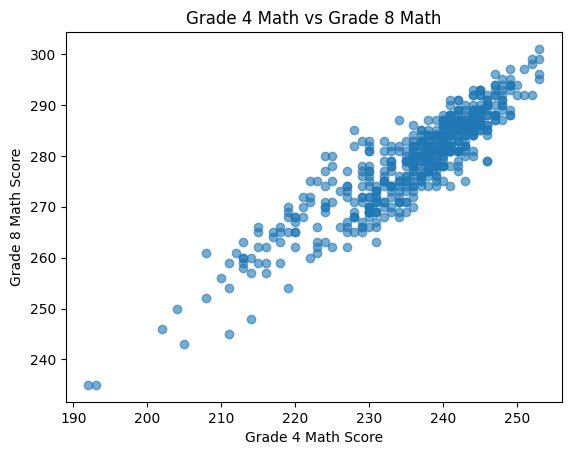

In [497]:
# @@@ 6
plt.scatter(
    df["AVG_MATH_4_SCORE"],
    df["AVG_MATH_8_SCORE"],
    alpha=0.6
)

plt.xlabel("Grade 4 Math Score")
plt.ylabel("Grade 8 Math Score")
plt.title("Grade 4 Math vs Grade 8 Math")
plt.show()


Grade 4 Math shows a clear positive linear relationship with Grade 8 Math. The relatively tight clustering around an upward trend is consistent with the high correlation coefficient (~0.91), making Grade 4 Math a strong candidate predictor.

**Visualization 2**

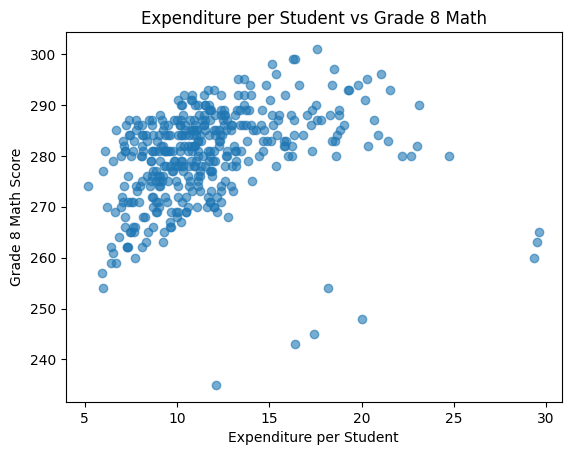

In [498]:
plt.scatter(
    df["EXPENDITURE_PER_STUDENT"],
    df["AVG_MATH_8_SCORE"],
    alpha=0.6
)

plt.xlabel("Expenditure per Student")
plt.ylabel("Grade 8 Math Score")
plt.title("Expenditure per Student vs Grade 8 Math")
plt.show()

Expenditure per student shows a much weaker positive relationship with Grade 8 Math. The points are more dispersed, indicating that spending alone explains substantially less variation in math performance than prior academic achievement.   

<h2> Data Creation </h2>

_Use this space to create train/test data_

In [499]:
from sklearn.model_selection import train_test_split

In [500]:
features = [
    "AVG_MATH_4_SCORE",
    "AVG_READING_8_SCORE",
    "AVG_READING_4_SCORE",
    "EXPENDITURE_PER_STUDENT", 
    "INSTRUCTION_PER_STUDENT"
]

model_df = df[features + [target]].dropna()

In [501]:
# @@@ 8

X = model_df[features]
y = model_df[target]
print("Model observations:", len(model_df))

Model observations: 357


After restricting the dataset to observations with complete values for all selected predictors and the target, 357 observations remained. This is substantially fewer than the 602 observations with a valid Grade 8 Math score, showing that missing predictor data is a meaningful limitation of the dataset.

In [502]:
# @@@ 9 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

<h2> Prediction </h2>

ML Models [Resource](https://medium.com/@vijaya.beeravalli/comparison-of-machine-learning-classification-models-for-credit-card-default-data-c3cf805c9a5a)

In [503]:
# @@@ 10
# import your sklearn class here
from sklearn.linear_model import LinearRegression

In [504]:
# @@@ 11
# create your model here

model = LinearRegression() 

In [505]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [506]:
y_pred = model.predict(X_test)

## Evaluation

Choose some metrics to evaluate the performance of your model, some of them are mentioned in the tutorial.

In [507]:
# @@@ 12
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.67620568894462
RMSE: 2.063770054794593
R²: 0.9341203969180103


In [508]:
train_pred = model.predict(X_train)

print("Train R²:", r2_score(y_train, train_pred))
print("Test R²:", r2_score(y_test, y_pred))

Train R²: 0.9179455959149576
Test R²: 0.9341203969180103


I chose the following metrics : 
- MAE : represents the average prediction error . 
- RMSE : penalizes larger errors more heavily
- R^2 : measuses how much of the variation of the target variable (Grade 8 Math) was explained by the model

Overall, the MAE result means that it is a good prediction, only differing from the mean about 1.7 points on average.RMSE is only moderately larger than MAE, suggesting that the model does not suffer from many extremely large prediction errors. An R² of 0.934 indicates that approximately 93.4% of the variation in Grade 8 Math scores in the test set is explained by the selected predictors.

We have copied over the graphs that visualize the model's performance on the training and testing set. 

Change `col_name` and modify the call to `plt.ylabel()` to isolate how a single predictor affects the model.

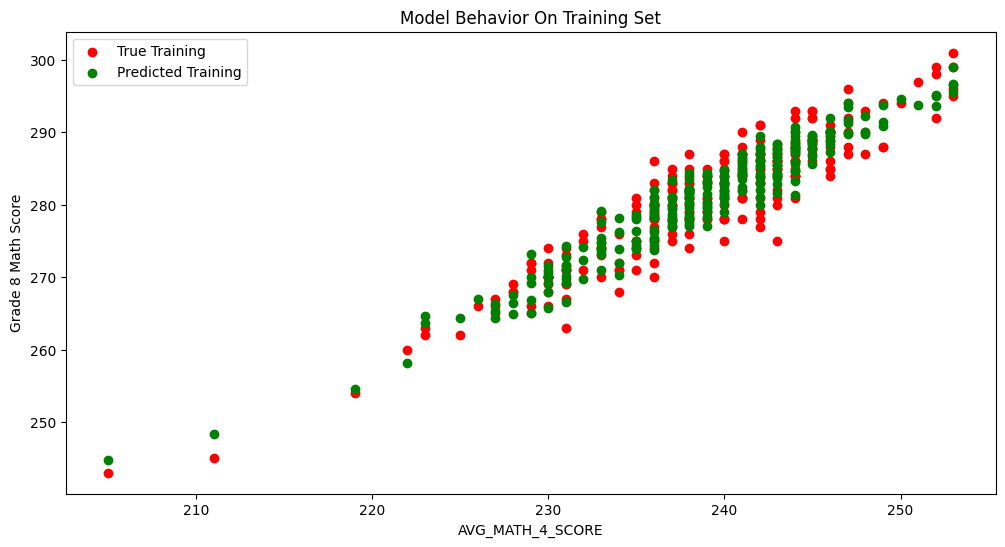

In [509]:
# @@@ 13

col_name =  "AVG_MATH_4_SCORE"


f = plt.figure(figsize=(12,6))

plt.scatter(X_train[col_name], y_train, color = "red")
plt.scatter(X_train[col_name], model.predict(X_train), color = "green")

plt.legend(['True Training','Predicted Training'])
plt.xlabel(col_name)
plt.ylabel('Grade 8 Math Score')
plt.title("Model Behavior On Training Set")
plt.show() 

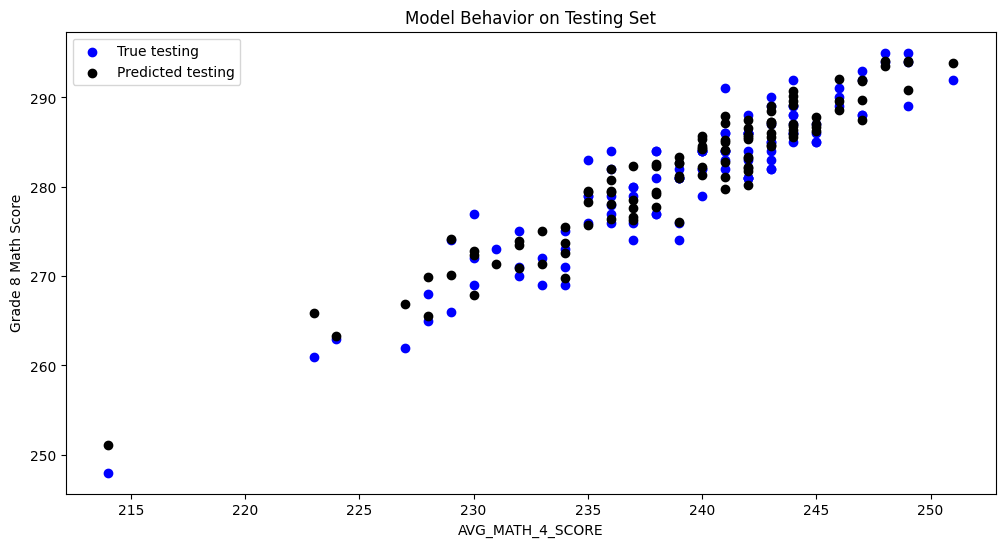

In [510]:
# @@@ 14

f = plt.figure(figsize=(12,6))
plt.scatter(X_test[col_name], y_test, color = "blue")
plt.scatter(X_test[col_name], model.predict(X_test), color = "black")

plt.legend(['True testing','Predicted testing'])
plt.xlabel(col_name)
plt.ylabel("Grade 8 Math Score")
plt.title("Model Behavior on Testing Set")
plt.show()


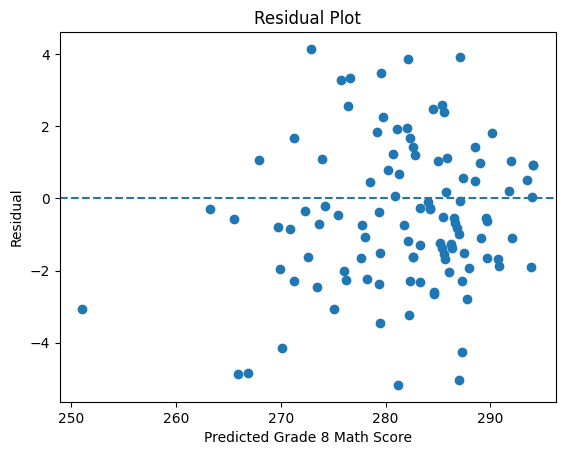

In [511]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Grade 8 Math Score")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

The residuals are largely centered around zero without an obvious systematic pattern, which supports the use of a linear model. A few larger residuals remain, corresponding to observations that the model predicts less accurately.

## ALTERNATIVE MODELS 

RIDGE REGRESSION

Now, well test a Ridge Regression because we have many predictors that are correlated with each other , so incorporating a regularization of these coefficents may improve the overall performance. 

For doing this, we need to standarize the features. I chose to do this simply using the Pipeline and StandarScaler 

In [512]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

for alpha in [0.5, 1.0, 1.5, 2.0]: 
    ridge = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])
    ridge.fit(X_train, y_train)

    ridge_pred = ridge.predict(X_test)
    print (f" ---RIDGE FOR ALPHA {alpha}---")
    print("Ridge R²:", r2_score(y_test, ridge_pred))
    print("Ridge MAE:", mean_absolute_error(y_test, ridge_pred))
    print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))

 ---RIDGE FOR ALPHA 0.5---
Ridge R²: 0.9342233249150975
Ridge MAE: 1.67681955558371
Ridge RMSE: 2.0621572433748443
 ---RIDGE FOR ALPHA 1.0---
Ridge R²: 0.9342579884172874
Ridge MAE: 1.6776484256223114
Ridge RMSE: 2.061613805963388
 ---RIDGE FOR ALPHA 1.5---
Ridge R²: 0.9342322509427669
Ridge MAE: 1.6790373400277714
Ridge RMSE: 2.062017319176077
 ---RIDGE FOR ALPHA 2.0---
Ridge R²: 0.9341530220109712
Ridge MAE: 1.680409655906466
Ridge RMSE: 2.063258978340515


Ridge performs almost identically across the tested alpha values, with the best result occurring around alpha = 1.0. The differences are negligible, so regularization provides no meaningful improvement over ordinary Linear Regression.

LASSO 

We also want to test Lasso and see if its eliminating redundant information

In [513]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

for alpha in [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]:

    lasso = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=alpha, max_iter=10000))
    ])

    lasso.fit(X_train, y_train)
    lasso_pred = lasso.predict(X_test)

    print(f"--- LASSO alpha={alpha} ---")
    print("R2:", r2_score(y_test, lasso_pred))
    print("MAE:", mean_absolute_error(y_test, lasso_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))

--- LASSO alpha=0.001 ---
R2: 0.934164261749101
MAE: 1.675547788424042
RMSE: 2.063082877014171
--- LASSO alpha=0.01 ---
R2: 0.9344051191497307
MAE: 1.6697934471484932
RMSE: 2.0593055661970876
--- LASSO alpha=0.05 ---
R2: 0.9333681729248494
MAE: 1.6779095534519226
RMSE: 2.0755188431995926
--- LASSO alpha=0.1 ---
R2: 0.9305745025244041
MAE: 1.7081984910595167
RMSE: 2.1185822035576742
--- LASSO alpha=0.5 ---
R2: 0.9142351743992585
MAE: 1.858715761029419
RMSE: 2.3547262433297234
--- LASSO alpha=1.0 ---
R2: 0.899548149474211
MAE: 2.0055859711984914
RMSE: 2.5483835351019306


Lasso Regression achieved performance similar to ordinary Linear Regression while shrinking some predictor coefficients toward zero. This suggests that part of the information contained in the predictors is redundant, particularly among the highly correlated academic variables.

In [514]:
best_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.01, max_iter=10000))
])

best_lasso.fit(X_train, y_train)

coefficients = best_lasso.named_steps["lasso"].coef_

pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": coefficients
})

,Feature,Coefficient
0,AVG_MATH_4_SCORE,6.001671
1,AVG_READING_8_SCORE,4.998616
2,AVG_READING_4_SCORE,-2.530841
3,EXPENDITURE_PER_STUDENT,0.500994
4,INSTRUCTION_PER_STUDENT,-0.479086


Lasso shrinks the coefficients of the engineered financial variables substantially compared with the academic predictors, suggesting that they contribute relatively little additional predictive information. However, at the best-performing alpha (0.01), neither financial feature is completely eliminated.

RANDOM FOREST MODEL

Also, it is interesting to use a non-linear model. 

In [515]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


In [516]:
mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
r2 = r2_score(y_test, rf_pred)

print ("MAE : ", mae)
print("RMSE : ", rmse)
print("R2 : ", r2)

MAE :  1.961064814814813
RMSE :  2.495813207116032
R2 :  0.903649822764868


The Random Forest model performs worse than the linear models, with a lower R² and higher MAE and RMSE. This suggests that the relationships between the selected predictors and Grade 8 Math are largely captured by a linear model, and additional nonlinear flexibility does not improve generalization in this case. Since the dataset is relatively small, a more flexible model such as Random Forest may also have less data available to reliably learn complex nonlinear patterns.

In [517]:
rf_train_pred = rf.predict(X_train)

print("Train R2:", r2_score(y_train, rf_train_pred))
print("Test R2:", r2_score(y_test, rf_pred))

Train R2: 0.9852260660992788
Test R2: 0.903649822764868


Random Forest achieves extremely high training performance (R² ≈ 0.985) but substantially lower test performance (R² ≈ 0.905). This generalization gap indicates overfitting: the model is fitting training-specific patterns that do not transfer as well to unseen data.

GRADIENT BOOSTING

In [518]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)

In [519]:
mae = mean_absolute_error(y_test, gbr_pred)
rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))
r2 = r2_score(y_test, gbr_pred)

print ("MAE : ", mae)
print("RMSE : ", rmse)
print("R2 : ", r2)

MAE :  1.9905033170707238
RMSE :  2.520551721183229
R2 :  0.9017303096066094


Gradient Boosting performs similarly to Random Forest but is slightly worse on all three test metrics. Both nonlinear models underperform the linear models and show a noticeable train-test gap, suggesting that the additional model complexity does not improve generalization for this dataset.

In [520]:
gbr_train_pred = gbr.predict(X_train)

print("Train R2:", r2_score(y_train, gbr_train_pred))
print("Test R2:", r2_score(y_test, gbr_pred))

Train R2: 0.9742540760652446
Test R2: 0.9017303096066094


Gradient Boosting reduces the overfitting observed in Random Forest slightly, but a sizeable train-test gap remains. Its test performance is still below the linear models, suggesting that added nonlinear complexity is unnecessary for the current feature set.

## CROSS - VALIDATION

In [521]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring="r2"
)

print("CV R2 scores:", scores)
print("Mean CV R2:", scores.mean())
print("Std CV R2:", scores.std())

CV R2 scores: [0.93809269 0.90545756 0.9129276  0.90133659 0.85474089]
Mean CV R2: 0.9025110675905369
Std CV R2: 0.02707990644331613


To verify that the strong test performance was not due to a particularly favorable train/test split, I performed 5-fold cross-validation. The model achieved a mean R² of approximately 0.903 with a standard deviation of 0.027. This indicates that the model performs consistently well across different subsets of the data, although some variation exists between folds.

The cross-validation mean is slightly lower than the single test-set R² (~0.93), suggesting that the original split may have been somewhat favorable, but overall the model still shows strong generalization.

# CONCLUSION

Overall, Grade 8 Math is strongly predicted by previous and related academic performance measures, while engineered financial variables provide much less additional information. The academic predictors are highly correlated with one another, but regularized models such as Ridge and Lasso did not meaningfully improve predictive performance. 

More complex nonlinear models, including Random Forest and Gradient Boosting, performed worse and showed greater overfitting. Ordinary Linear Regression therefore provided the best balance of simplicity, interpretability, and predictive performance. Its average 5-fold cross-validation R² of about 0.90 indicates that the model generalizes consistently well across different subsets of the data.